# Fitzpatrick EDA

Tasks
- [x] Find out classes present
- [x] Show example images
- [x] Check if there is class imbalance
- [x] Make sure classes can be logically collapsed to our other classes we have
- [x] Save out the final X's for this dataset

In [11]:
import pandas as pd
from pathlib import Path
from IPython.display import display
from label_mappings import STRICT_LABEL_MAP, FULL_LABEL_MAP
import altair as alt
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from urllib.parse import urlsplit

REPOROOT = Path('..').resolve()

METADATA_PATH = REPOROOT / 'data' / 'fitzpatrick17k.csv'
IMG_DIR = REPOROOT / 'data_preprocessed'

METADATA_PREPROCESSED_DIR = REPOROOT / 'metadata_preprocessed'
METADATA_PREPROCESSED_DIR.mkdir(exist_ok=True)


In [12]:
def sync_metadata_and_image_dir(img_dir: str | Path, metadata: pd.DataFrame):
    """
    Filter metadata to only include images in the image directory.\
    
    :param img_dir: The directory containing the images.
    :param metadata: DataFrame containing the Fitzpatrick metadata.
    :returns: The filtered Fitzpatrick metadata, so it contains only the images of interest.
    """
    img_dir = Path(img_dir)
    assert img_dir.is_dir(), "img_dir must be a directory"
    img_hashes = [
        f.stem for f in img_dir.iterdir() if 
        f.is_file() and 
        not str(f.name).endswith(".csv") and 
        not str(f.name).startswith('.')
    ]

    return metadata.set_index('md5hash').loc[img_hashes, :].reset_index().copy()

In [13]:
# load data
fitzpatrick_metadata = pd.read_csv(METADATA_PATH)
fitzpatrick_metadata = sync_metadata_and_image_dir(IMG_DIR, fitzpatrick_metadata)
fitzpatrick_metadata.head()

,md5hash,fitzpatrick_scale,fitzpatrick_centaur,label,nine_partition_label,three_partition_label,qc,url,url_alphanum
0,163d9c550fad4704990a3d1b8183d0f8,2,2,melanoma,malignant melanoma,malignant,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicmmelan...
1,8da0ad261c76d6ed8587ad2275664650,5,5,lichen planus,inflammatory,non-neoplastic,NaN,http://atlasdermatologico.com.br/img?imageId=3863,httpwwwatlasdermatologicocombrimgimageId3863.jpg
2,bf4f6cfabebd719230e63966697b9e58,5,1,drug eruption,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicddruge...
3,1e3947e35a705843429a47848fe29eb6,4,4,lupus erythematosus,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicLlupus...
4,eb9acf3ecf71fd86dca542b99a2d0f53,5,5,striae,inflammatory,non-neoplastic,NaN,http://atlasdermatologico.com.br/img?imageId=6879,httpwwwatlasdermatologicocombrimgimageId6879.jpg


In [14]:
fitzpatrick_metadata['qc'].value_counts()

qc
1 Diagnostic          163
5 Potentially          36
2 Characteristic        9
3 Wrongly labelled      7
4 Other                 2
Name: count, dtype: int64

In [15]:
# drop "wrongly labeled" and "other"
keep_flg = ~fitzpatrick_metadata['qc'].isin(('3 Wrongly labelled', '4 Other'))
fitzpatrick_metadata = fitzpatrick_metadata[keep_flg]
fitzpatrick_metadata['qc'].value_counts()

qc
1 Diagnostic        163
5 Potentially        36
2 Characteristic      9
Name: count, dtype: int64

In [ ]:
fitzpatrick_metadata['url'].apply(lambda x: pd.NA if pd.isna(x) else urlsplit(x).netloc).value_counts()

url
atlasdermatologico.com.br    3887
www.dermaamin.com            2800
Name: count, dtype: int64

- dermaamin is all clincal images, per their [homepage](www.dermaamin.com)
- atlasdermatologico also looks like clinical images, not dermatoscope

# Basic Statistics

- classes present
- number of images in each class

In [16]:
print("Total images:", fitzpatrick_metadata.shape[0])
print("Number of classes (label):", fitzpatrick_metadata['label'].drop_duplicates().shape[0])
print("Number of images in each class (label):")
class_counts_label = fitzpatrick_metadata['label'].value_counts().to_frame(name="count")
display(class_counts_label)

class_counts_label.to_clipboard()

Total images: 6689
Number of classes (label): 114
Number of images in each class (label):


,count
label,
basal cell carcinoma,310
squamous cell carcinoma,301
lichen planus,289
psoriasis,233
pityriasis rubra pilaris,202
...,...
neurodermatitis,12
basal cell carcinoma morpheiform,9
xanthomas,7


In [17]:
print("Number of classes (label):", fitzpatrick_metadata['nine_partition_label'].drop_duplicates().shape[0])
print("Number of images in each class (nine_partition_label):")
display(fitzpatrick_metadata['nine_partition_label'].value_counts().to_frame(name="count"))

Number of classes (label): 9
Number of images in each class (nine_partition_label):


,count
nine_partition_label,
inflammatory,4275
malignant epidermal,693
genodermatoses,562
benign epidermal,365
benign dermal,354
malignant melanoma,202
malignant cutaneous lymphoma,104
malignant dermal,69
benign melanocyte,65


DermaMNIST classes:

```
actinic keratoses and intraepithelial carcinoma=327, 
basal cell carcinoma=514,
benign keratosis-like lesions=1099, 
dermatofibroma=115, 
melanoma=1113, 
melanocytic nevi=6705,
vascular lesions=142
```

These classes do not exactly correspond with the 9 classes in the Fitzpatrick dataset.

AI Usage: asked ChatGPT if we can correspond the 9 classes in fitzpatrick with the 7 classes in DermaMNIST.
- Result: we cannot map the 9 classes, but we can map the 114 classes
- Here, I perform the mapping, then run EDA on the mapped labels.
- ChatGPT gave me two mappings: a strict one (for strict matches) and a looser one that includes things that can be argued to match but may not match as well as the strict

- I also asked ChatGPT to provide references to the mappings it created, and I checked the references to ensure it did the mapping properly. Upon further checking, I decided we should NOT use the optional mappings as they do not correspond strictly to the HAM10000 definitions that the training data is based on. I left the code for them in this EDA, however, in case it is needed, but we should go with the strict mapping.

Link to AI chat: https://sandbox.ai.huit.harvard.edu/share/1ILJ7CpjivneXU4X2zRNd


# Map To DermaMNIST

Here, I will map our fitzpatrick images to the DermaMNIST labels. I will do the mapping both for the strict and the less strict class mappings.

In [18]:
# map labels to DermaMNIST
fitzpatrick_metadata['dermamnist_label_strict'] = fitzpatrick_metadata['label'].apply(lambda x: STRICT_LABEL_MAP.get(x, None))
fitzpatrick_metadata['dermamnist_label_lenient'] = fitzpatrick_metadata['label'].apply(lambda x: FULL_LABEL_MAP.get(x, None))
fitzpatrick_metadata.head()

,md5hash,fitzpatrick_scale,fitzpatrick_centaur,label,nine_partition_label,three_partition_label,qc,url,url_alphanum,dermamnist_label_strict,dermamnist_label_lenient
0,163d9c550fad4704990a3d1b8183d0f8,2,2,melanoma,malignant melanoma,malignant,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicmmelan...,melanoma,melanoma
1,8da0ad261c76d6ed8587ad2275664650,5,5,lichen planus,inflammatory,non-neoplastic,NaN,http://atlasdermatologico.com.br/img?imageId=3863,httpwwwatlasdermatologicocombrimgimageId3863.jpg,NaN,NaN
2,bf4f6cfabebd719230e63966697b9e58,5,1,drug eruption,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicddruge...,NaN,NaN
3,1e3947e35a705843429a47848fe29eb6,4,4,lupus erythematosus,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicLlupus...,NaN,NaN
4,eb9acf3ecf71fd86dca542b99a2d0f53,5,5,striae,inflammatory,non-neoplastic,NaN,http://atlasdermatologico.com.br/img?imageId=6879,httpwwwatlasdermatologicocombrimgimageId6879.jpg,NaN,NaN


In [19]:
dermamnist_strict_flg = fitzpatrick_metadata['dermamnist_label_strict'].notna()
dermamnist_lenient_flg = fitzpatrick_metadata['dermamnist_label_lenient'].notna()

print("Class counts with DermaMNIST labels:")
print("Total images (strict):", fitzpatrick_metadata[dermamnist_strict_flg].shape[0])
print("Number of classes (strict):", fitzpatrick_metadata[dermamnist_strict_flg]['dermamnist_label_strict'].drop_duplicates().shape[0])
print("Number of images in each class (strict):")
class_counts_strict = fitzpatrick_metadata[dermamnist_strict_flg]['dermamnist_label_strict'].value_counts().to_frame(name="count")
display(class_counts_strict)

Class counts with DermaMNIST labels:
Total images (strict): 802
Number of classes (strict): 7
Number of images in each class (strict):


,count
dermamnist_label_strict,
basal cell carcinoma,336
melanoma,202
vascular lesions,103
melanocytic nevi,65
actinic keratoses and intraepithelial carcinoma,56
dermatofibroma,26
benign keratosis-like lesions,14


In [20]:
print("Total images (lenient):", fitzpatrick_metadata[dermamnist_lenient_flg].shape[0])
print("Number of classes (lenient):", fitzpatrick_metadata[dermamnist_lenient_flg]['dermamnist_label_lenient'].drop_duplicates().shape[0])
print("Number of images in each class (lenient):")
class_counts_lenient = fitzpatrick_metadata[dermamnist_lenient_flg]['dermamnist_label_lenient'].value_counts().to_frame(name="count")
display(class_counts_lenient)

Total images (lenient): 884
Number of classes (lenient): 7
Number of images in each class (lenient):


,count
dermamnist_label_lenient,
basal cell carcinoma,336
melanoma,202
vascular lesions,172
melanocytic nevi,78
actinic keratoses and intraepithelial carcinoma,56
dermatofibroma,26
benign keratosis-like lesions,14


In [21]:
strict_chart = alt.Chart(class_counts_strict.reset_index()).mark_bar().encode(
    x=alt.X("dermamnist_label_strict:N", sort="-y"),
    y="count:Q"
)

lenient_chart = alt.Chart(class_counts_lenient.reset_index()).mark_bar().encode(
    x=alt.X("dermamnist_label_lenient:N", sort="-y"),
    y="count:Q"
)

strict_chart | lenient_chart

alt.HConcatChart(...)

There is a lot of class imbalance. Some of our classes will not be tested much with this dataset.

# Example Images

Here, I will show some example images.

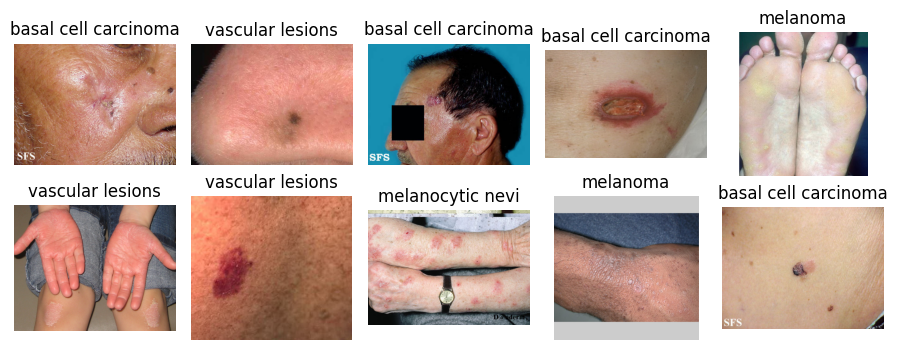

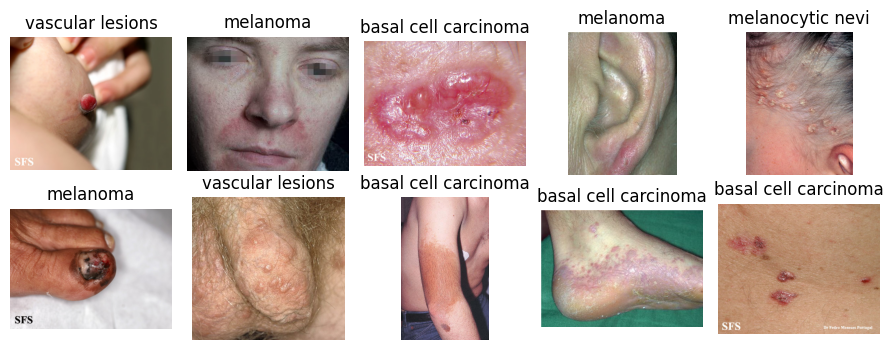

In [22]:
# this code was plagiarized from BMI 712 Pset 1
def show_examples(
        metadata: pd.DataFrame, 
        img_dir: str | Path, 
        label_col: str,
        n_rows=2, 
        n_cols=5
    ):
    idxs = np.random.randint(low=0, high=metadata.shape[0], size=n_rows * n_cols)
    img_dir = Path(img_dir)
    assert img_dir.is_dir(), "img_dir must be a directory"

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.8 * n_cols, 1.8 * n_rows))
    axes = axes.ravel()

    for ax, idx in zip(axes, idxs):
        example = metadata.iloc[int(idx)]
        label = example[label_col]
        img_hash = example['md5hash']
        img_files = [i for i in img_dir.iterdir() if i.suffix != '.csv' and not str(i.name).startswith(".")]
        img_hash_to_path = {i.stem:i for i in img_files}

        with Image.open(img_hash_to_path[img_hash]) as img:

            img_arr = np.asarray(img)

            ax.imshow(img_arr)

            ax.set_title(label)
            ax.axis("off")

    plt.tight_layout()

# show examples (strict)
show_examples(fitzpatrick_metadata[dermamnist_strict_flg], IMG_DIR, 'dermamnist_label_strict')
# show examples (lenient)
show_examples(fitzpatrick_metadata[dermamnist_lenient_flg], IMG_DIR, 'dermamnist_label_lenient')

# Save out Final Images

In [ ]:
# save updated metadata files
fitzpatrick_metadata[dermamnist_strict_flg].to_csv(METADATA_PREPROCESSED_DIR / 'fitzpatrick17k_strict_collapsed.csv', index=False)
fitzpatrick_metadata[dermamnist_lenient_flg].to_csv(METADATA_PREPROCESSED_DIR / 'fitzpatrick17k_lenient_collapsed.csv', index=False)